<a href="https://colab.research.google.com/github/GDMenezes/Second_MVP_ML_Analytics/blob/main/MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: *Machine Learning & Analytics*


**Nome:** Gabriel Silva Menezes

**Matrícula:** 4052025000123

**Dataset:** [Industria de Consumo Data](https://raw.githubusercontent.com/GDMenezes/Second_MVP_ML_Analytics/refs/heads/main/Base_Vendas_2024.csv)

# Descrição do Problema

A empresa Well Being vem sofrendo com elevados níveis de estoque, tanto de produtos acabados quanto de insumos, pois trabalha no modelo Make to Stock (produz com base em previsões de demanda e armazena em estoque). A empresa oferece soluções de cuidados pessoais nos segmentos de higiênicos, papel toalha, fraldas e guardanapos. O gerente de Logística solicitou uma análise dos dados de pedidos produzidos no ano de 2024, pois precisa de um norte para o ano de 2025, a fim de ajustar os estoques e o lead time dos insumos, reduzindo custos tanto logísticos quanto industriais.


## Tipo de Problema

Este é um problema que podemos testar utilizando tanto **regressão supervisionada** quanto **previsão de séries temporais (Forecasting)**, cujo objetivo é prever um valor numérico com base em variáveis de entrada. Neste projeto, utilizarei modelos de regressão, pois foram amplamente utilizados na disciplina.

## Seleção de Dados

Procurei por *datasets* referentes ao tema de previsão de demanda, com dados mais próximos da realidade da minha área de conhecimento (logística), mas não encontrei. Por isso, decidi escrever as diretrizes que gostaria de ver em um *dataset*, com base em experiências do dia a dia nas empresas.
Feito isso, passei as diretrizes ao ChatGPT e solicitei ajuda para gerar um *dataset* de acordo com as diretrizes passadas. O resultado foi o mais próximo que encotrei da realidade dos problemas enfrentados no cotidiano. Em seguida, realizei algumas alterações no código e cheguei a um exemplo de *dataset* que gostaria de aplicar o conhecimento adquirido nas aulas.

## Atributos do Dataset

O dataset Indústria de Consumo Data contém 392.830 amostras com 6 atributos. Segue abaixo uma contextualização dos atributos:

- ***Data_de_Venda:*** Data que a venda foi realizada.
- ***Nome_do_Produto:*** SKU - identificação do produto / item.
- ***Quantidade_Vendida:*** Quantidade de vendas realizadas.
- ***Preço_Unitário:*** Preço unitário que o produto foi vendido.
- ***Região_de_Venda:*** Região que o produto foi vendido no Brasil.
- ***Promoção_Ativa:*** Se o item vendido estava em promoção naquela data.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para análise, visualização, pré-processamento dos dados e construção de modelos de *machine learning*, bem como carregamento inicial do *dataset*.

In [2]:
# Importação de pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # Utilizado para fazer o OneHotEncoding
from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.linear_model import LinearRegression # algoritmo Regressão Linear
from sklearn.neighbors import KNeighborsRegressor # algoritmo KNN
from sklearn.linear_model import Lasso # algoritmo Regularização Lasso
from sklearn.linear_model import Ridge # algoritmo Regularização Ridge
from sklearn.tree import DecisionTreeRegressor # algoritmo Árvore de Regressão
from sklearn.metrics import accuracy_score # para a exibição da acurácia do modelo
from sklearn.metrics import mean_squared_error # métrica de avaliação MSE

# Configuração para não exibir os warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")


In [3]:
# Carregamento do dataset que ficará disponível através da variável file
file = "https://raw.githubusercontent.com/GDMenezes/Second_MVP_ML_Analytics/refs/heads/main/Base_Vendas_2024.csv"

In [4]:
# É atribuido o dataset ao df(dataframe) - Colocando a coluna de Data de Venda como indice
df = pd.read_csv(file)

In [5]:
# Visão geral do dataframe, como informações das primeiras e últimas linhas, informando também quantidade de linhas e colunas
df

,Data_de_Venda,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa
0,2024-01-07,Papel Higiênico 30m,5,5.35,Nordeste,Não
1,2024-01-07,Papel Higiênico 30m,7,5.29,Sudeste,Não
2,2024-01-07,Lenço Umedecido,17,5.05,Centro-Oeste,Não
3,2024-01-07,Papel Toalha FD,13,6.91,Sul,Não
4,2024-01-07,Papel Higiênico 50m,19,8.15,Sul,Sim
...,...,...,...,...,...,...
392825,2024-12-29,Fralda P,19,26.13,Sul,Não
392826,2024-12-29,Papel Higiênico 30m,29,5.96,Sul,Sim
392827,2024-12-29,Fralda P,35,25.83,Sudeste,Não
392828,2024-12-29,Lenço Umedecido,15,5.19,Nordeste,Não


# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA) sobre o *dataset* Indústria de Consumo Data, busca-se compreender a distribuição, as relações e as características dos dados, com o objetivo de embasar a análise final.

## Total e Tipo das Instâncias

O dataset possui um total de 392.830 instâncias (observações), sendo 2 do tipo numérico (int / float64) e 4 do tipo categórico (objetc).

In [6]:
# Verificando informações do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392830 entries, 0 to 392829
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Data_de_Venda       392830 non-null  object 
 1   Nome_do_Produto     392830 non-null  object 
 2   Quantidade_Vendida  392830 non-null  int64  
 3   Preço_Unitário      392830 non-null  float64
 4   Região_de_Venda     392830 non-null  object 
 5   Promoção_Ativa      392830 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 18.0+ MB


## Verificando e Tratando o Dataframe

Será carregado o dataframe com mais informações e feitas algumas alterações, como consultado, o df está com o formato object na coluna Data_de_Venda, não é o correto, iremos tratar essa coluna e criar mais 3 colunas para análise.

In [7]:
df.dtypes

,0
Data_de_Venda,object
Nome_do_Produto,object
Quantidade_Vendida,int64
Preço_Unitário,float64
Região_de_Venda,object
Promoção_Ativa,object


In [8]:
# Alterando o tipo da coluna Data_de_Venda para datetime, utilizado para trabalhar com datas
df["Data_de_Venda"] = pd.to_datetime(df["Data_de_Venda"])

In [9]:
# Adicionando uma coluna com informação do ano apenas, para facilitar análises futuras
df['Year'] = df["Data_de_Venda"].dt.year

In [10]:
# Adicionando uma coluna com a informação do mês apenas, nos auxiliará nas análises e no modelo.
df['Month'] = df['Data_de_Venda'].dt.month_name()

In [11]:
# Adicionando uma coluna que nos mostra a receita obtida por cada venda, poderá nos auxiliar em indicadores.
df['Receita'] = df['Quantidade_Vendida'] * df['Preço_Unitário']

In [12]:
# Verificando as primeiras linhas do dataset após o tratamento.
df.head()

,Data_de_Venda,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
0,2024-01-07,Papel Higiênico 30m,5,5.35,Nordeste,Não,2024,January,26.75
1,2024-01-07,Papel Higiênico 30m,7,5.29,Sudeste,Não,2024,January,37.03
2,2024-01-07,Lenço Umedecido,17,5.05,Centro-Oeste,Não,2024,January,85.85
3,2024-01-07,Papel Toalha FD,13,6.91,Sul,Não,2024,January,89.83
4,2024-01-07,Papel Higiênico 50m,19,8.15,Sul,Sim,2024,January,154.85


In [13]:
# Informações atualizadas do DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392830 entries, 0 to 392829
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Data_de_Venda       392830 non-null  datetime64[ns]
 1   Nome_do_Produto     392830 non-null  object        
 2   Quantidade_Vendida  392830 non-null  int64         
 3   Preço_Unitário      392830 non-null  float64       
 4   Região_de_Venda     392830 non-null  object        
 5   Promoção_Ativa      392830 non-null  object        
 6   Year                392830 non-null  int32         
 7   Month               392830 non-null  object        
 8   Receita             392830 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 25.5+ MB


In [14]:
# Verificando se temos valores nulos
df.isna().sum()

,0
Data_de_Venda,0
Nome_do_Produto,0
Quantidade_Vendida,0
Preço_Unitário,0
Região_de_Venda,0
Promoção_Ativa,0
Year,0
Month,0
Receita,0


In [15]:
# Verificando a quantidade de itens unicos do dataset
df.nunique()

,0
Data_de_Venda,52
Nome_do_Produto,10
Quantidade_Vendida,384
Preço_Unitário,2005
Região_de_Venda,5
Promoção_Ativa,2
Year,1
Month,12
Receita,86358


In [16]:
# Verificando quais regiões a empresa possui vendas
df.Região_de_Venda.unique()

array(['Nordeste', 'Sudeste', 'Centro-Oeste', 'Sul', 'Norte'],
      dtype=object)

In [17]:
# Verificando o nome dos itens comercializados pela empresa.
df.Nome_do_Produto.unique()

array(['Papel Higiênico 30m', 'Lenço Umedecido', 'Papel Toalha FD',
       'Papel Higiênico 50m', 'Papel Higiênico 40m', 'Fralda M',
       'Fralda G', 'Fralda P', 'Fralda XG', 'Papel Toalha FT'],
      dtype=object)

## Análises com Gráficos

Nos blocos abaixo, serão realizadas algumas análises com auxílio de gráficos para melhor visualização dos dados.

Abaixo utilizarei um gráfico para auxiliar na visualização do ranking de vendas dos produtos.

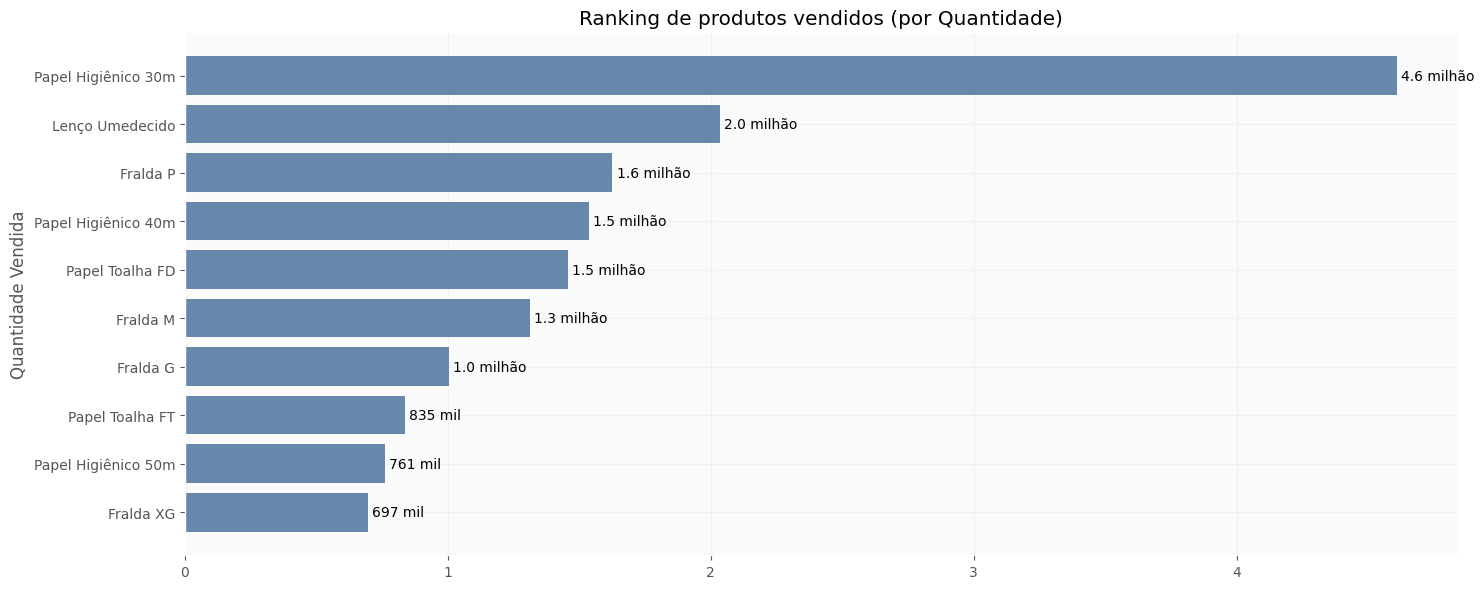

In [18]:
# Agrupar por produto e somar a quantidade
mais_vendidos = df.groupby('Nome_do_Produto')['Quantidade_Vendida'].sum().sort_values(ascending=True)

# Define uma cor default
corDefault = '#6688AA'

# Carrega uma folha de estilo (opcional - questão estética)
plt.style.use('ggplot')

# Modifica mais alguns parâmetros gráficos (opcional - questão estética)
plt.rc('axes', facecolor='#fafafa', grid = True)
plt.rc('grid', color = '#f0f0f0')

# Prepara a figura (fig) e a área do gráfico (ax) com Largura 15 e altura 6
fig, ax = plt.subplots(figsize = (15, 6))

# Plota o gráfico de barras
b1 = ax.barh(mais_vendidos.index, mais_vendidos.values/1e6, color = corDefault)

#Formatando o número da leganda da barra do gráfico
labels = []
for v in mais_vendidos.values:
    if v >= 1_000_000:
        labels.append(f'{v/1_000_000:.1f} milhão')
    elif v >= 1_000:
        labels.append(f'{v/1_000:.0f} mil')
    else:
        labels.append(str(v))

# Acrescenta os valores sobre as barras
ax.bar_label(b1, labels=labels, padding=3)

# Acrescenta um título ao gráfico
plt.title('Ranking de produtos vendidos (por Quantidade)')

# Define os rótulos dos eixos
# plt.xlabel('Produto') # como já está no título, não é necessário
# É importante esclarecer a unidade e a ordem de grandeza
plt.ylabel('Quantidade Vendida')

# Ajustar as margens do gráfico (para eliminar margens desnecessárias)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

Com base no ranking dos produtos mais vendidos, analisaremos a curva de vendas dos cinco primeiros, para verificar a Curva de Vendas Semanais.

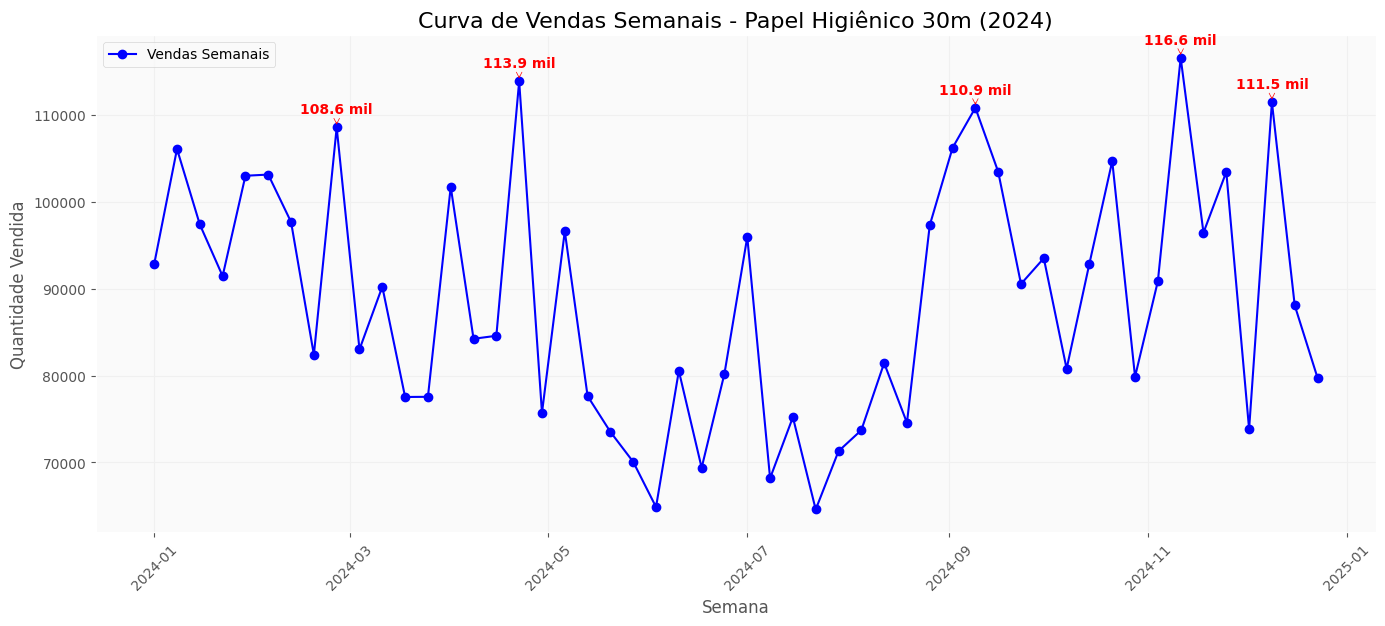

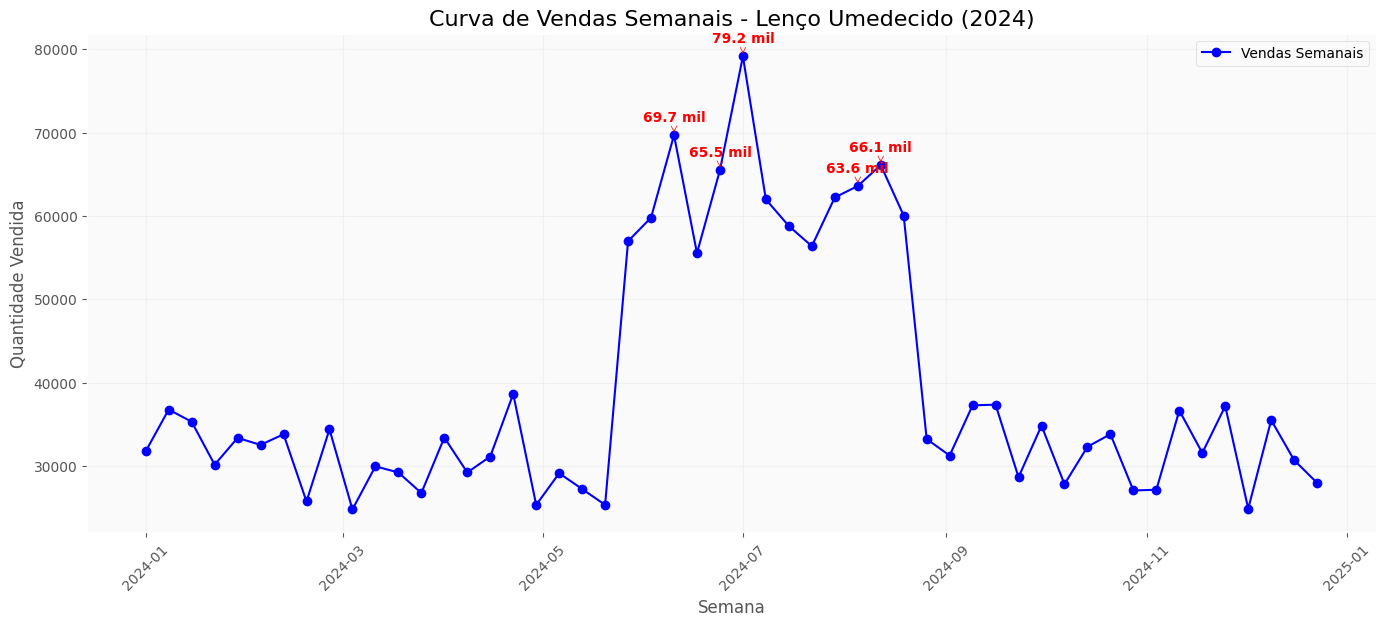

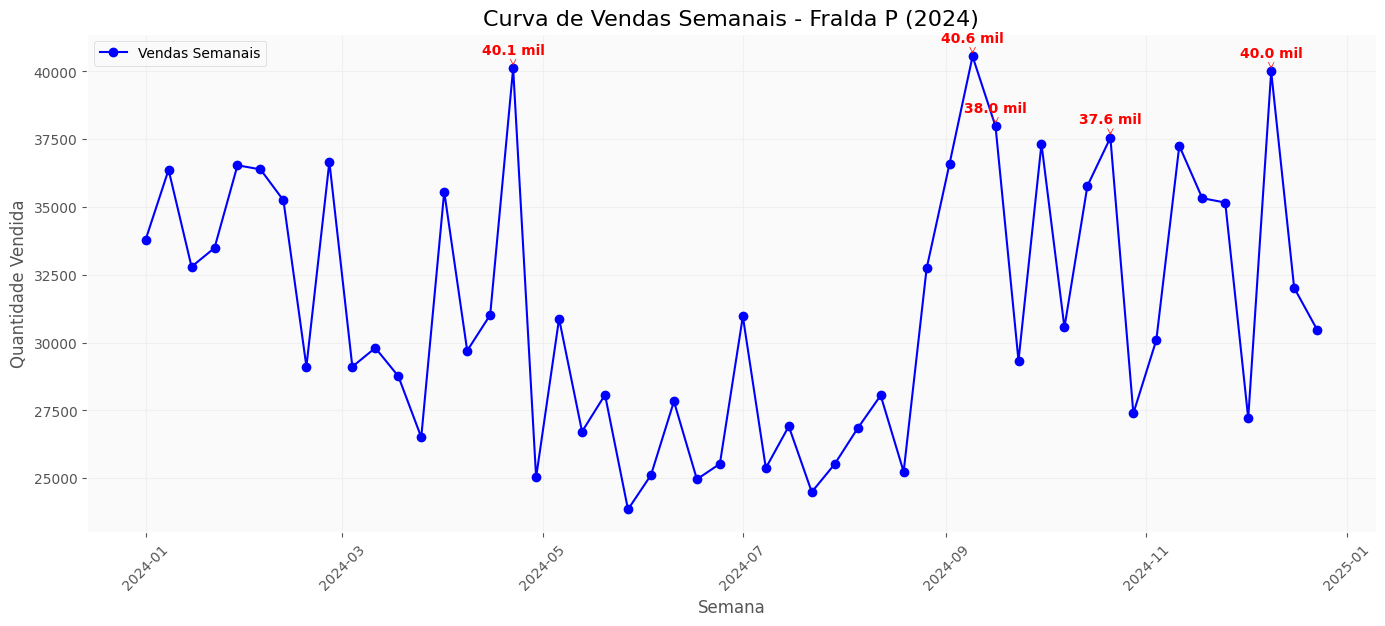

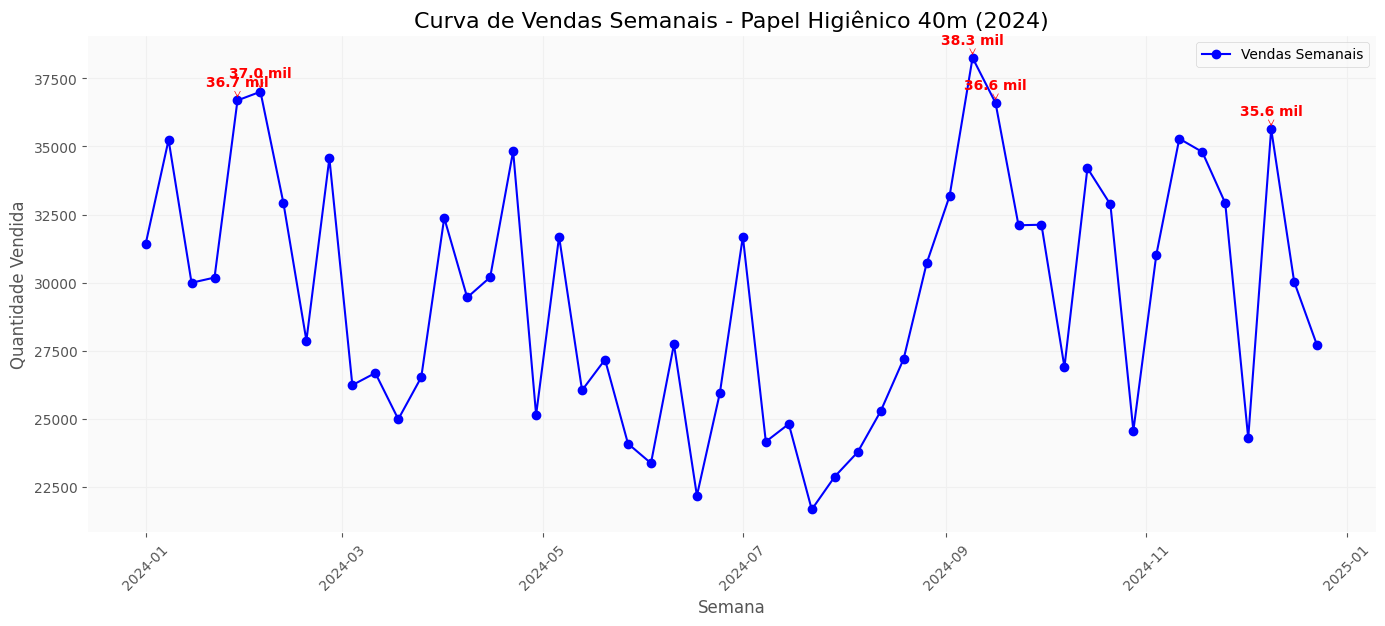

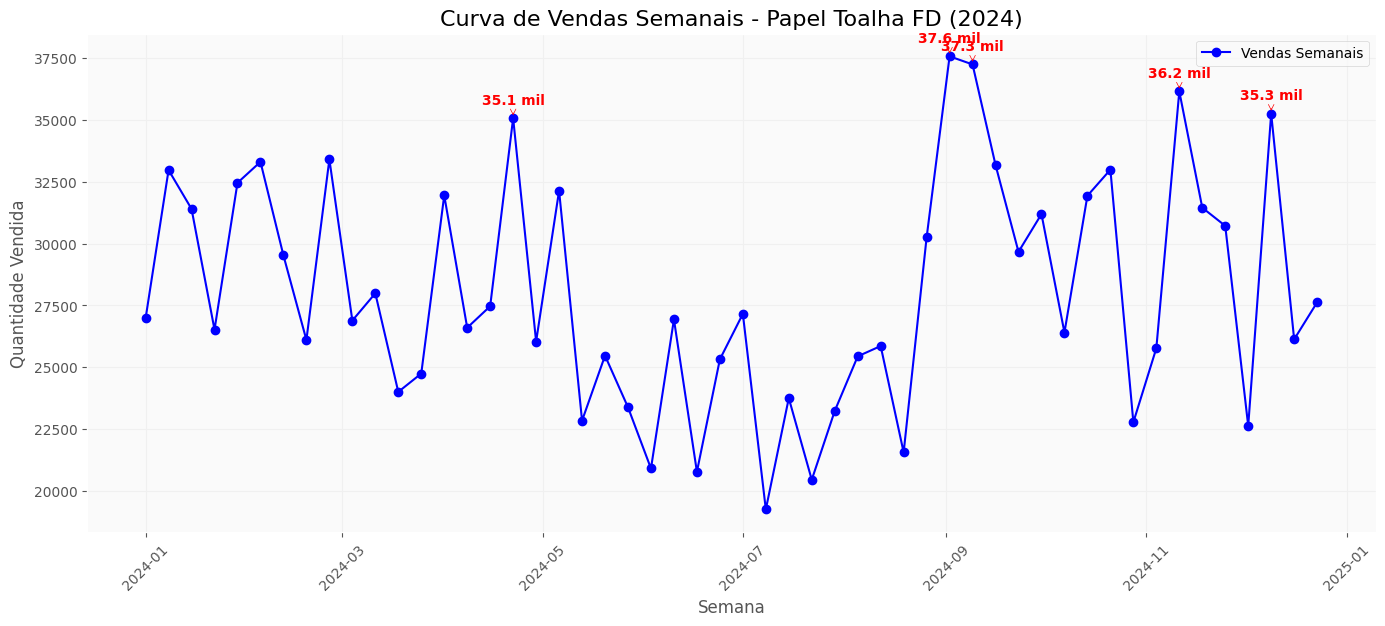

In [19]:
# Função de formatação dos valores
def formatar_valor(valor):
    if valor >= 1_000_000:
        return f"{valor / 1_000_000:.1f} mi"
    elif valor >= 1_000:
        return f"{valor / 1_000:.1f} mil"
    else:
        return str(valor)

# 1. Identificar os 5 produtos mais vendidos
mais_vendidos = (
    df.groupby('Nome_do_Produto')['Quantidade_Vendida']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# 2. Gerar os gráficos automaticamente
for produto in mais_vendidos:
    df_produto = df[df["Nome_do_Produto"] == produto].copy()

    # Agrupar por semana
    df_produto["Semana"] = df_produto["Data_de_Venda"].dt.to_period("W").apply(lambda r: r.start_time)
    vendas_semanais = df_produto.groupby("Semana")["Quantidade_Vendida"].sum()

    # Selecionar os 5 maiores picos de venda
    top_picos = vendas_semanais.sort_values(ascending=False).head(5)

    # Plotar o gráfico
    plt.figure(figsize=(14, 6), num=None, clear=True)
    plt.plot(vendas_semanais.index, vendas_semanais.values, marker='o', linestyle='-', color='blue', label='Vendas Semanais')

    # Anotar os picos
    for data, quantidade in top_picos.items():
        texto_formatado = formatar_valor(quantidade)
        plt.annotate(texto_formatado, xy=(data, quantidade), xytext=(0, 10),
                     textcoords='offset points', ha='center', color='red',
                     fontsize=10, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='red'))

    # Personalização
    plt.title(f"Curva de Vendas Semanais - {produto} (2024)", fontsize=16)
    plt.xlabel("Semana")
    plt.ylabel("Quantidade Vendida")
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

É possível observar algumas informações importantes nos conjuntos gráficos acima:

- As curvas não são lineares, elas variam de acordo com as semanas, meses e estações ao longo do ano.
- O Lenço Umedecido é o item que apresenta uma forte sazonalidade de acordo com a época do ano.
- Essa pode ser uma das razoes pelas quais e empresa vem enfrentando dificuldades para controlar o nível dos estoques.

Abaixo veremos um gráfico com o total de pedidos por mês referente ao ano de 2024

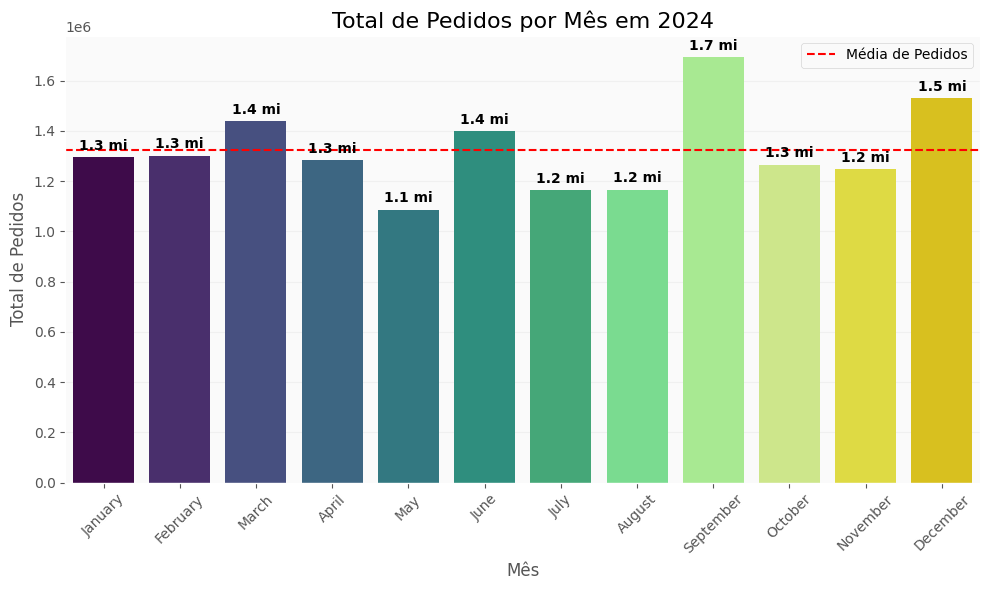

In [20]:
# Função para formatar os valores
def formatar_valor(valor):
    if valor >= 1_000_000:
        return f"{valor / 1_000_000:.1f} mi"
    elif valor >= 1_000:
        return f"{valor / 1_000:.1f} mil"
    else:
        return str(valor)

# Agrupar a demanda mensal
monthly_demand = df.groupby('Month')['Quantidade_Vendida'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

mean_demand = monthly_demand.mean()

# Paleta de cores Viridis (adaptada para daltônicos)
CoresViridis = ['#440154', '#482576', '#3e4a89', '#31688e', '#26828e', '#1f9e89',
                '#35b778', '#6aeb87', '#a1f883', '#d4f57c', '#f7f22b', '#f7d700']

# Criar figura e eixo
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=monthly_demand.index, y=monthly_demand.values, palette=CoresViridis)

# Linha da média
plt.axhline(mean_demand, color='red', linestyle='--', label='Média de Pedidos')

# Adicionar rótulos formatados em cima das barras
for i, value in enumerate(monthly_demand.values):
    texto_formatado = formatar_valor(value)
    ax.text(i, value + max(monthly_demand.values) * 0.01,  # leve deslocamento vertical
            texto_formatado,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalização
plt.title('Total de Pedidos por Mês em 2024', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Pedidos', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Estatísticas Descritivas e Boxplot

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [21]:
# Estatísticas descritivas básicas do dataset
df.describe()

,Data_de_Venda,Quantidade_Vendida,Preço_Unitário,Year,Receita
count,392830,392830.000000,392830.000000,392830.0,392830.000000
mean,2024-07-03 18:19:32.183387392,40.403831,12.496825,2024.0,505.668179
min,2024-01-07 00:00:00,1.000000,3.920000,2024.0,4.150000
25%,2024-03-31 00:00:00,12.000000,5.450000,2024.0,95.370000
50%,2024-07-07 00:00:00,28.000000,6.620000,2024.0,239.610000
75%,2024-10-06 00:00:00,56.000000,25.470000,2024.0,558.000000
max,2024-12-29 00:00:00,474.000000,38.150000,2024.0,11940.060000
std,NaN,39.785964,10.217825,0.0,767.142304


In [22]:
# Carregar variaveis numéricas para o boxplot
variaveis_numericas = []
for i in df.columns[1:9].tolist():
    if df.dtypes[i] == 'int64' or df.dtypes[i] == 'float64':
        print(i, ':' , df.dtypes[i])
        variaveis_numericas.append(i)

Quantidade_Vendida : int64
Preço_Unitário : float64
Receita : float64


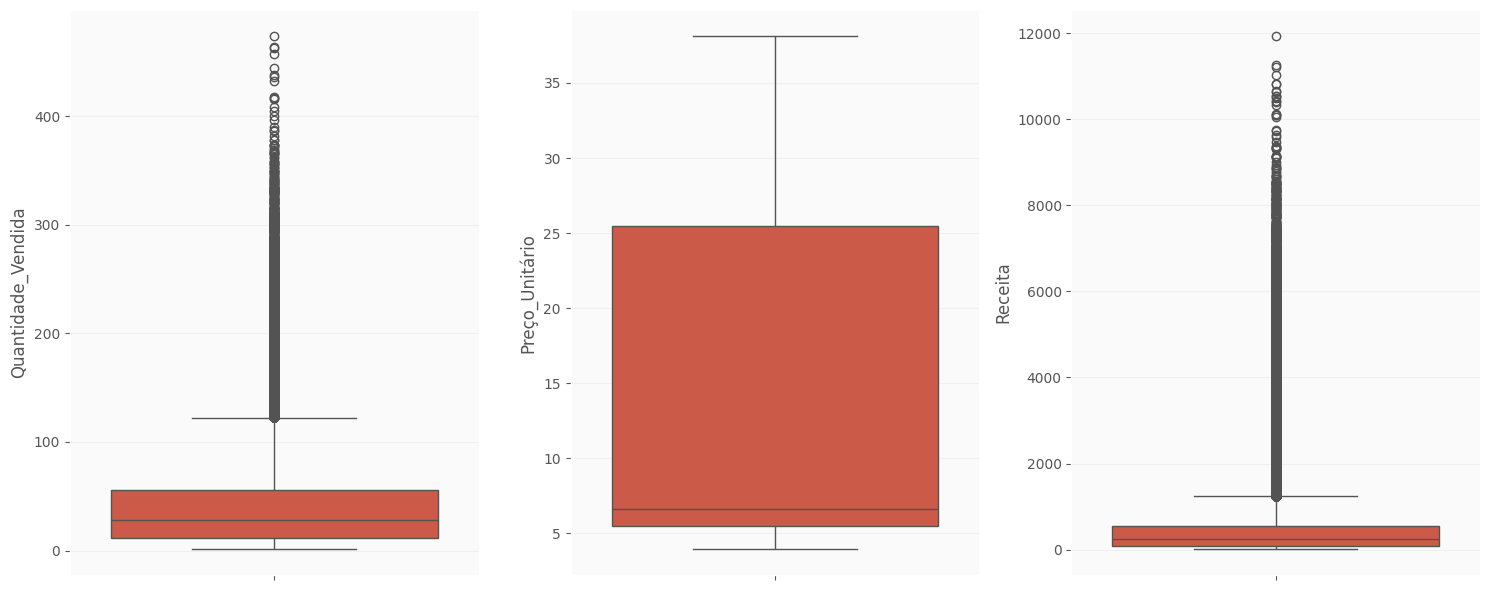

In [23]:
# Gerando o boxplot com variáveis numéricas
num_vars = len(variaveis_numericas)
f, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste automático do tamanho

# Se houver apenas 1 variável, axes não será uma lista
if num_vars == 1:
    axes = [axes]

for idx, var in enumerate(variaveis_numericas):
    sns.boxplot(data=df, y=var, ax=axes[idx])

plt.tight_layout()
plt.show()

In [24]:
# Verificando algumas das maiores quantidades vendidas
df.loc[df['Quantidade_Vendida']>370]

,Data_de_Venda,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
31767,2024-01-28,Lenço Umedecido,382,4.57,Sudeste,Não,2024,January,1745.74
33518,2024-02-04,Papel Higiênico 50m,378,7.85,Norte,Não,2024,February,2967.30
53362,2024-02-18,Fralda P,371,25.18,Nordeste,Sim,2024,February,9341.78
54113,2024-02-18,Lenço Umedecido,416,4.70,Sudeste,Sim,2024,February,1955.20
76819,2024-03-10,Papel Higiênico 30m,417,5.69,Centro-Oeste,Não,2024,March,2372.73
83180,2024-03-17,Fralda P,405,25.71,Nordeste,Não,2024,March,10412.55
88197,2024-03-24,Papel Toalha FT,432,7.63,Sudeste,Não,2024,March,3296.16
94655,2024-03-31,Papel Toalha FD,438,7.72,Sul,Não,2024,March,3381.36
127976,2024-04-28,Fralda XG,378,29.18,Sudeste,Não,2024,April,11030.04
156047,2024-05-26,Papel Higiênico 40m,372,6.25,Sudeste,Não,2024,May,2325.00


É possível observar informações importantes na análise acima:

- **Quantidade_Vendida:** Alguns valores altos estão destoando do restante dos dados, indicando possíveis outliers. No entanto, no contexto do Negócio em questão, esses valores não devem ser tratados como outliers, pois a empresa atende diversos tipos de clientes, incluindo distribuidores com maior poder de compra, que conseguem negociar preços e obter descontos por volume. O que justifica volumes de vendas significativamente maiores.

# Pré-Processamento de Dados e definição do Target

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [39]:
#Criando uma cópia do Dataframe, para caso haja algum erro não voltar tudo do começo
df2 = df.copy()
df2.head(6)

,Data_de_Venda,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
0,2024-01-07,Papel Higiênico 30m,5,5.35,Nordeste,Não,2024,January,26.75
1,2024-01-07,Papel Higiênico 30m,7,5.29,Sudeste,Não,2024,January,37.03
2,2024-01-07,Lenço Umedecido,17,5.05,Centro-Oeste,Não,2024,January,85.85
3,2024-01-07,Papel Toalha FD,13,6.91,Sul,Não,2024,January,89.83
4,2024-01-07,Papel Higiênico 50m,19,8.15,Sul,Sim,2024,January,154.85
5,2024-01-07,Papel Higiênico 40m,99,6.51,Norte,Não,2024,January,644.49


In [40]:
#Removendo coluna de Data_de_Venda que não será utilizada na análise
df2 = df2.drop('Data_de_Venda', axis=1)

In [41]:
df2.head()

,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
0,Papel Higiênico 30m,5,5.35,Nordeste,Não,2024,January,26.75
1,Papel Higiênico 30m,7,5.29,Sudeste,Não,2024,January,37.03
2,Lenço Umedecido,17,5.05,Centro-Oeste,Não,2024,January,85.85
3,Papel Toalha FD,13,6.91,Sul,Não,2024,January,89.83
4,Papel Higiênico 50m,19,8.15,Sul,Sim,2024,January,154.85


Será utilizado o Label Encoding, para converter as variáveis categóricas em valores numéricos. Pois os algoritmos de Machine Learning que utilizaremos só entender números.

In [42]:
# Criar o encoder
lb = LabelEncoder()

# Aplica o encoder nas variáveis que estão com string
df2['Nome_do_Produto'] = lb.fit_transform(df2['Nome_do_Produto'])
df2['Região_de_Venda'] = lb.fit_transform(df2['Região_de_Venda'])
df2['Promoção_Ativa'] = lb.fit_transform(df2['Promoção_Ativa'])
df2['Month'] = lb.fit_transform(df2['Month'])

In [43]:
# Visualizar as primeiras 5 linhas do Dataset, para verificar se o Label Encoding funcionou
df2.head(5)

,Nome_do_Produto,Quantidade_Vendida,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
0,5,5,5.35,1,0,2024,4,26.75
1,5,7,5.29,3,0,2024,4,37.03
2,4,17,5.05,0,0,2024,4,85.85
3,8,13,6.91,4,0,2024,4,89.83
4,7,19,8.15,4,1,2024,4,154.85


In [44]:
# Mostra as informações do Dataframe
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392830 entries, 0 to 392829
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Nome_do_Produto     392830 non-null  int64  
 1   Quantidade_Vendida  392830 non-null  int64  
 2   Preço_Unitário      392830 non-null  float64
 3   Região_de_Venda     392830 non-null  int64  
 4   Promoção_Ativa      392830 non-null  int64  
 5   Year                392830 non-null  int32  
 6   Month               392830 non-null  int64  
 7   Receita             392830 non-null  float64
dtypes: float64(2), int32(1), int64(5)
memory usage: 22.5 MB


In [45]:
# Mover a coluna 'Quantidade_Vendida' para a última posição usando .insert(), pois é a variável target
df2.insert(7, 'Quantidade_Vendida', df2.pop('Quantidade_Vendida'))

In [46]:
# Mostra as informações do Dataframe
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392830 entries, 0 to 392829
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Nome_do_Produto     392830 non-null  int64  
 1   Preço_Unitário      392830 non-null  float64
 2   Região_de_Venda     392830 non-null  int64  
 3   Promoção_Ativa      392830 non-null  int64  
 4   Year                392830 non-null  int32  
 5   Month               392830 non-null  int64  
 6   Receita             392830 non-null  float64
 7   Quantidade_Vendida  392830 non-null  int64  
dtypes: float64(2), int32(1), int64(5)
memory usage: 22.5 MB


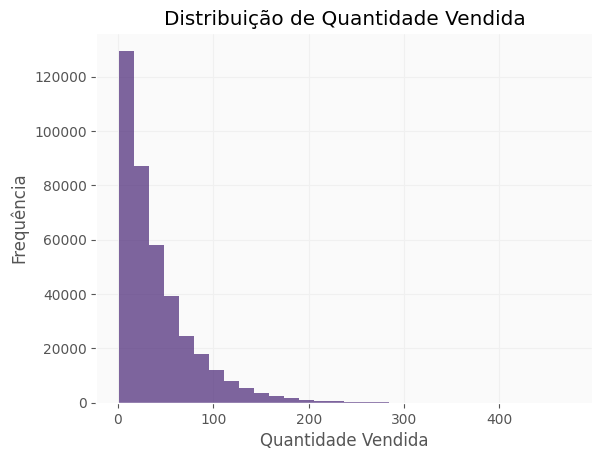

In [47]:
# Analisando como a variável target está distribuida, através de um Histrograma
plt.hist(df2['Quantidade_Vendida'], bins=30, color='#482576', alpha=0.7)
plt.title('Distribuição de Quantidade Vendida')
plt.xlabel('Quantidade Vendida')
plt.ylabel('Frequência')
plt.show()

O histrograma mostra que temos uma distribuição assimétrica à direita, onde a maioria das vendas está concentrada em valores pequenos e há algumas vendas muito grandes (cauda longa). Isso indica que uma pequena parte dos produtos geram uma grande parte da receita, o que é comum em cenários de negócio.

Será aplicada uma técnica chamada de transformação logarítmica, pois dados assimétricos à direita, podem afetar negativamente o desempenho de modelos estatísticos e de machine learning, especialmente os modelos lineares que serão utilizados nesse projeto.

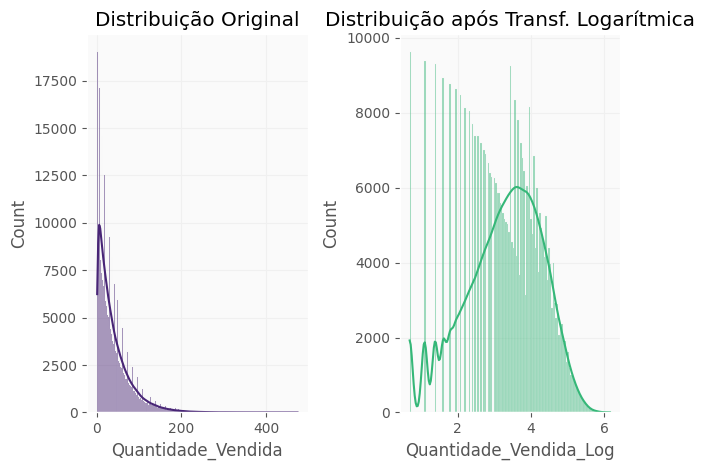

In [48]:
# Passo 1: Aplicar a transformação logarítmica
df2['Quantidade_Vendida_Log'] = np.log(df2['Quantidade_Vendida'] + 1)

# Subplot 1: Histograma da "Quantidade_Vendida"
plt.subplot(1, 2, 1)
sns.histplot(df2['Quantidade_Vendida'], kde=True, color='#482576')
plt.title('Distribuição Original')

# Subplot 2: Histograma da "Quantidade_Vendida_Log"
plt.subplot(1, 2, 2)
sns.histplot(df2['Quantidade_Vendida_Log'], kde=True, color='#35b778')
plt.title('Distribuição após Transf. Logarítmica')

plt.tight_layout()
plt.show()

In [49]:
# Preparação dos dados

# Separar variaveis preditoras e target (holdout)
preditoras = df2.iloc[:,0:7]
target = df2.iloc[:,7]

In [50]:
preditoras.head()

,Nome_do_Produto,Preço_Unitário,Região_de_Venda,Promoção_Ativa,Year,Month,Receita
0,5,5.35,1,0,2024,4,26.75
1,5,5.29,3,0,2024,4,37.03
2,4,5.05,0,0,2024,4,85.85
3,8,6.91,4,0,2024,4,89.83
4,7,8.15,4,1,2024,4,154.85


In [51]:
target.head()

,Quantidade_Vendida
0,5
1,7
2,17
3,13
4,19


# Treinamento e Avalição dos Modelos

Nesta etapa, serão realizadas a separação dos dados em bases de treino e teste, a escolha dos modelos, o treinamento e a estimativa das métricas MSE e RMSE.

In [52]:
# Separação da bases de treino e teste
x_train, x_test, y_train, y_test = train_test_split(preditoras, target, test_size=0.20, random_state=7) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7) # faz o particionamento em 10 folds

LR: MSE 631.77 (10.96) - RMSE 25.14
Ridge: MSE 631.77 (10.96) - RMSE 25.14
Lasso: MSE 631.78 (10.98) - RMSE 25.14
KNN: MSE 17.00 (4.11) - RMSE 4.12
CART: MSE 0.60 (0.36) - RMSE 0.78


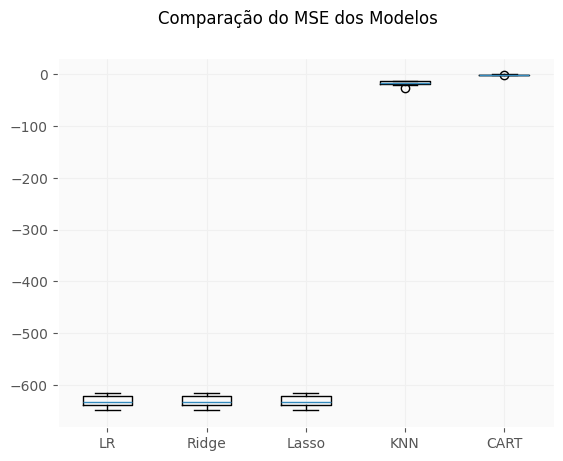

In [53]:
# Modelagem

# Definindo uma seed global para esta célula de código
np.random.seed(7)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('LR', LinearRegression()))
models.append(('Ridge', Ridge()))
models.append(('Lasso', Lasso()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))

# Avaliando um modelo por vez
for name, model in models:
  cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
  results.append(cv_results)
  names.append(name)
  # imprime MSE, desvio padrão do MSE e RMSE dos 10 resultados da validação cruzada
  msg = "%s: MSE %0.2f (%0.2f) - RMSE %0.2f" % (name, abs(cv_results.mean()), cv_results.std(), np.sqrt(abs(cv_results.mean())))
  print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação do MSE dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

Os modelos Lineares (LR, Ridge, Lasso) apresentaram desempenho muito semelhante.
- MSE e RMSE são praticamente idênticos, todos os três modelos estão se ajustando da mesma forma as dados. Sugerindo que os dados não têm uma relação linear forte com a variável-alvo. Relarizações (Ridge e Lasso) não trouxeram ganhos sobre a regressão linear simples.
- Modelos não lineares (KNN e CART) superaram os lineares com folga. Isso sugere que o problema não tem uma estrutura linear, os modelos lineares não captaram bem.
- CART foi o modelo que melhor se ajustou aos dados.

Utilizando o modelo com todo o conjunto de treino e fazendo predições com o conjunto de teste.

In [54]:
# Criando um modelo com todo o conjunto de treino
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

# Fazendo as predições com o conjunto de teste
predictions = model.predict(x_test)

# Estimando o MSE e o RMSE no conjunto de teste
mse = mean_squared_error(y_test, predictions)
print("MSE %0.2f" % mse)
print("RMSE %0.2f" % np.sqrt(abs(mse)))

MSE 0.42
RMSE 0.64


Agora, utilizaremos três modelos (LR, KNN e CART) nas bases original e transformada por logaritmo, para verificar se a transformação ajuda a melhorar a performance.

In [55]:
# Construir o modelo de Regressão Linear usando dados originais
model_original = LinearRegression()
model_original.fit(x_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_original = model_original.predict(x_test)

# Avaliar o modelo original
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))

# Imprimir as métricas para o modelo original
print("Modelo Original")
print(f"MSE: {mse_original}")
print(f"RMSE: {rmse_original}")

Modelo Original
MSE: 634.4949734618929
RMSE: 25.189183660092933


In [56]:
# Agora, vamos aplicar a transformação logarítmica na variável target
y_train_log = np.log(y_train + 1)
y_test_log = np.log(y_test + 1)

# Construir o modelo de Regressão Linear usando os dados transformados (log)
model_log = LinearRegression()
model_log.fit(x_train, y_train_log)

# Fazer previsões no conjunto de teste (com dados log transformados)
y_pred_log = model_log.predict(x_test)

# Reverter a transformação logarítmica para as previsões (exp() - 1)
y_pred_log_original_scale = np.exp(y_pred_log) - 1

# Avaliar o modelo com os dados transformados
mse_log = mean_squared_error(y_test, y_pred_log_original_scale)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_original_scale))

# Imprimir as métricas para o modelo log transformado
print("\nModelo com Transformação Logarítmica")
print(f"MSE: {mse_log}")
print(f"RMSE: {rmse_log}")


Modelo com Transformação Logarítmica
MSE: 39427103.56626267
RMSE: 6279.100537996081


In [57]:
# Construir o modelo de KNN usando dados originais
model_original = KNeighborsRegressor()
model_original.fit(x_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_original = model_original.predict(x_test)

# Avaliar o modelo original
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))

# Imprimir as métricas para o modelo original
print("Modelo Original")
print(f"MSE: {mse_original}")
print(f"RMSE: {rmse_original}")

Modelo Original
MSE: 15.651480793218438
RMSE: 3.9561952420499216


In [58]:
# Agora, vamos aplicar a transformação logarítmica na variável target
y_train_log = np.log(y_train + 1)
y_test_log = np.log(y_test + 1)

# Construir o modelo de KNN usando os dados transformados (log)
model_log = KNeighborsRegressor()
model_log.fit(x_train, y_train_log)

# Fazer previsões no conjunto de teste (com dados log transformados)
y_pred_log = model_log.predict(x_test)

# Reverter a transformação logarítmica para as previsões (exp() - 1)
y_pred_log_original_scale = np.exp(y_pred_log) - 1

# Avaliar o modelo com os dados transformados
mse_log = mean_squared_error(y_test, y_pred_log_original_scale)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_original_scale))

# Imprimir as métricas para o modelo log transformado
print("\nModelo com Transformação Logarítmica")
print(f"MSE: {mse_log}")
print(f"RMSE: {rmse_log}")


Modelo com Transformação Logarítmica
MSE: 16.28097268296884
RMSE: 4.034968733827914


In [59]:
# Construir o modelo de CART usando dados originais
model_original = DecisionTreeRegressor()
model_original.fit(x_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_original = model_original.predict(x_test)

# Avaliar o modelo original
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))

# Imprimir as métricas para o modelo original
print("Modelo Original")
print(f"MSE: {mse_original}")
print(f"RMSE: {rmse_original}")

Modelo Original
MSE: 0.45765343787388946
RMSE: 0.6765008779550027


In [60]:
# Agora, vamos aplicar a transformação logarítmica na variável target
y_train_log = np.log(y_train + 1)
y_test_log = np.log(y_test + 1)

# Construir o modelo de CART usando os dados transformados (log)
model_log = DecisionTreeRegressor()
model_log.fit(x_train, y_train_log)

# Fazer previsões no conjunto de teste (com dados log transformados)
y_pred_log = model_log.predict(x_test)

# Reverter a transformação logarítmica para as previsões (exp() - 1)
y_pred_log_original_scale = np.exp(y_pred_log) - 1

# Avaliar o modelo com os dados transformados
mse_log = mean_squared_error(y_test, y_pred_log_original_scale)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_original_scale))

# Imprimir as métricas para o modelo log transformado
print("\nModelo com Transformação Logarítmica")
print(f"MSE: {mse_log}")
print(f"RMSE: {rmse_log}")


Modelo com Transformação Logarítmica
MSE: 0.43793753022936194
RMSE: 0.6617684868814485


Resultado dos Modelos e Conclusão

Modelo Original LR (RMSE: 25.19):

RMSE = 25.19 indica que, em média, as previsões feitas pelo modelo com dados originais estão errando em cerca de 25 unidades de Quantidade Vendida.

Isso significa que, para cada previsão, o erro médio entre o valor real e o valor previsto pelo modelo é de aproximadamente 25 unidades.

Modelo com Transformação Logarítmica (RMSE: 6279.10):

RMSE = 6279.10 para o modelo com a transformação logarítmica é muito maior. Isso significa que, após a transformação logarítmica, o modelo está cometendo um erro muito maior em média, cerca de 6279 unidades. Esse valor é muito maior em comparação com o modelo original.

Isso provavelmente está ocorrendo porque a transformação logarítmica não é reversível de forma direta e, ao tentar retornar as previsões ao seu valor original (aplicando a exponenciação), o erro aumenta consideravelmente.

Utilizando os modelos KNN e CART tanto a base original quanto a com transformação logarítimica os resultados foram próximos. No CART a transformação logarítmica ajudou o modelo a obter uma leve melhora na previsão. Essa diferença, ainda que aparentemente pequena, mostra como transformações nos dados podem impactar positivamente no desempenho de modelos de machine learning, especiamente em dados com grande variabilidade.